之前的pyrovelocity运行结果一直会用缓，即只对500个细胞执行pyrovelocity速率预测

In [1]:
import cafe

# cafe.logger.setLevel("INFO")
cafe.logger.setLevel("DEBUG")

# cafe.settings.backend = "python_function"
cafe.settings.backend = "conda"
# cafe.settings.backend = "cfe_docker"
cafe.settings.save_external_data = True # save external data

[11/04/2025 11:23:02] INFO                                                                                                                                                                              
                                  _____     _ _ ______    _       ______            _                                                                                                                   
                                 / ____|   | | |  ____|  | |     |  ____|          | |                                                                                                                  
                                | |     ___| | | |__ __ _| |_ ___| |__  __  ___ __ | | ___  _ __ ___ _ __                                                                                               
                                | |    / _ \ | |  __/ _` | __/ _ \  __| \ \/ / '_ \| |/ _ \| '__/ _ \ '__|                                                                                          

                      DEBUG    Reading data from '/root/PyCode/scRNA/data/Pancreas/endocrinogenesis_day15.h5ad'...                                                                                      
[11/04/2025 11:23:03] DEBUG    transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                 
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                    

<Axes: title={'center': 'ref(clusters)'}, xlabel='X_umap1', ylabel='X_umap2'>

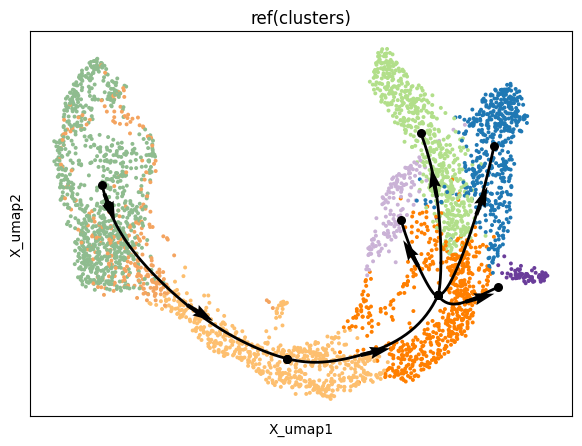

In [2]:
fadata = cafe.data.read_pancrease()
cafe.plot.plot_trajectory(fadata)

In [3]:
parameters = {"benchmark_resource": True}  # record resource usage
method = cafe.method.FateMethod(method_name="pyrovelocity")
method.infer_trajectory(fadata, parameters=parameters)

                      DEBUG    CondaBackend __init__                                                                                                                                                    
[11/04/2025 11:23:07] DEBUG    Conda environment 'pyrovelocity' found.                                                                                                                                  
[11/04/2025 11:23:09] DEBUG    Conda environment 'pyrovelocity' is available: Python 3.11.13                                                                                                            
                      DEBUG    Loaded function 'pyrovelocity': <function pyrovelocity at 0x70d1d2f020e0>                                                                                                
                      INFO     method backend loaded: CondaBackend: pyrovelocity in conda env 'pyrovelocity'                                                                                        

                      DEBUG    extract 'X_umap' from prior infomation as parameter 'basis'                                                                                                              
                      DEBUG    calculate new trajectory embedding for model_name:20251104_112309__pyrovelocity-conda__CriGFqwTEq, basis:X_umap.                                                         
                      DEBUG    add waypoints                                                                                                                                                            
                      DEBUG    FateAnnData add_waypoints                                                                                                                                                
[11/04/2025 11:32:24] DEBUG    add waypoints shape is (210, 3696) for '20251104_112309__pyrovelocity-conda__CriGFqwTEq', finished!                                                                  

<Axes: title={'center': 'pyrovelocity-conda(milestone)'}, xlabel='X_umap1', ylabel='X_umap2'>

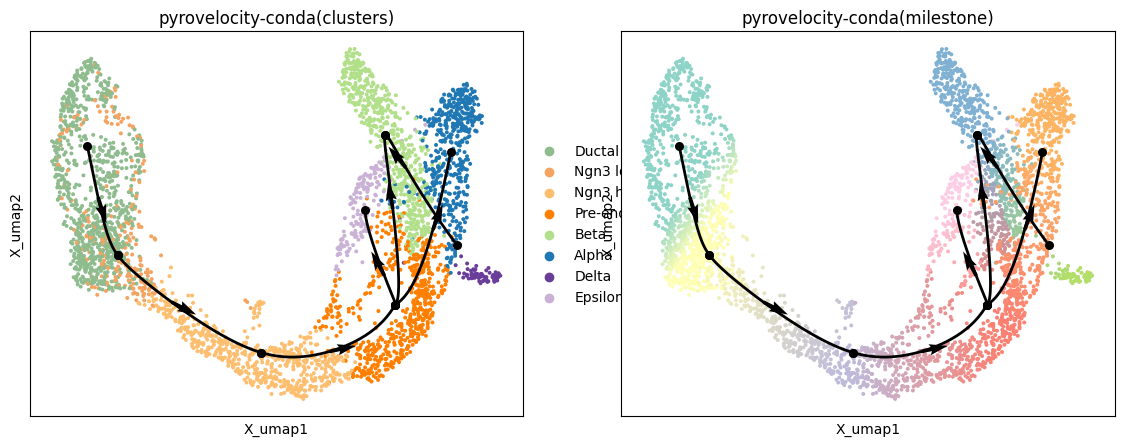

In [4]:
color_list = ["clusters", "milestone"]

cafe.plot.plot_trajectory(fadata, color=color_list)

In [6]:
fadata.write_trajectory_dict() 

[11/04/2025 11:33:01] DEBUG    write trajectory 'ref' to '.cfe/pancreas/trajectory_history/ref.pkl'                                                                                                     
                      DEBUG    write trajectory '20251104_112309__pyrovelocity-conda__CriGFqwTEq' to '.cfe/pancreas/trajectory_history/20251104_112309__pyrovelocity-conda__CriGFqwTEq.pkl'             
